# Salary Prediction using Age, Education, Job Title & Experience
**HR Analytics Project — AIML-Project-RollNo-XXXXX**

This notebook builds a Linear Regression model to predict candidate salary from Age, Gender, Education Level, Job Title, and Years of Experience, with a focus on feature engineering to improve model performance.

## 1. Data Collection
Load the dataset into a pandas DataFrame and inspect its structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
#/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Salary_Data.csv'
df = pd.read_csv('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Dataset/Salary_Data.csv')
print("Shape:", df.shape)
df.head()


Shape: (20160, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,46.0,Male,PhD,Director of Software Development,23.6,255800.0
1,32.0,Male,Bachelor's,Senior QA Engineer,11.2,141800.0
2,24.0,Male,Bachelor's,Cloud Support Engineer,4.0,69700.0
3,28.0,Male,Master's,Data Engineer,8.5,121600.0
4,34.0,Female,Master's,Technical Program Manager,11.8,147200.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  20060 non-null  float64
 1   Gender               20060 non-null  str    
 2   Education Level      20060 non-null  str    
 3   Job Title            20060 non-null  str    
 4   Years of Experience  20060 non-null  float64
 5   Salary               20060 non-null  float64
dtypes: float64(3), str(3)
memory usage: 1.6 MB


## 2. Data Cleaning
- Check missing values and duplicates
- Standardize `Education Level` text categories
- Drop/impute rows with missing `Salary` or `Years of Experience`
- Group rare job titles into `Other`

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Age                    100
Gender                 100
Education Level        100
Job Title              100
Years of Experience    100
Salary                 100
dtype: int64

Duplicate rows: 201


In [5]:
# Drop rows missing the target (Salary) or the key numeric driver (Years of Experience)
before = df.shape[0]
df = df.dropna(subset=['Salary', 'Years of Experience'])
print(f"Dropped {before - df.shape[0]} rows with missing Salary/Years of Experience.")

# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows.")

# For any remaining missing categorical values, impute with the mode
for col in ['Gender', 'Education Level', 'Job Title']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed missing '{col}' with mode: {mode_val}")

print("\nRemaining missing values:", df.isnull().sum().sum())


Dropped 100 rows with missing Salary/Years of Experience.
Dropped 102 duplicate rows.

Remaining missing values: 0


In [6]:
# Standardize Education Level text categories (handles variants like
# "Bachelor's" vs "Bachelor's Degree", "phd" vs "PhD", extra whitespace, etc.)
def standardize_education(val):
    v = str(val).strip().lower()
    if 'phd' in v or 'doctor' in v:
        return 'PhD'
    if 'master' in v or v == 'm.s.':
        return "Master's"
    if 'bachelor' in v or v == 'b.s.':
        return "Bachelor's"
    if 'high school' in v:
        return 'High School'
    return str(val).strip()

df['Education Level'] = df['Education Level'].apply(standardize_education)
print(df['Education Level'].value_counts())


Education Level
Bachelor's    9096
Master's      8543
PhD           2319
Name: count, dtype: int64


In [7]:
# Group job titles that appear fewer than a threshold number of times into 'Other'
MIN_COUNT = 5
title_counts = df['Job Title'].value_counts()
rare_titles = title_counts[title_counts < MIN_COUNT].index
df['Job Title Cleaned'] = df['Job Title'].apply(lambda t: 'Other' if t in rare_titles else t)

print(f"Original unique job titles: {df['Job Title'].nunique()}")
print(f"Job titles with >= {MIN_COUNT} occurrences (kept as-is): {df['Job Title'].nunique() - len(rare_titles)}")
print(f"Job titles grouped into 'Other': {len(rare_titles)}")
print(f"Unique values after grouping: {df['Job Title Cleaned'].nunique()}")
df['Job Title Cleaned'].value_counts().head(10)


Original unique job titles: 90
Job titles with >= 5 occurrences (kept as-is): 90
Job titles grouped into 'Other': 0
Unique values after grouping: 90


Job Title Cleaned
Data Analyst              338
Full Stack Developer      337
Software Test Engineer    336
Network Engineer          335
IT Consultant             334
Automation Engineer       323
Mobile App Developer      320
Web Developer             317
Frontend Developer        316
Cloud Support Engineer    315
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

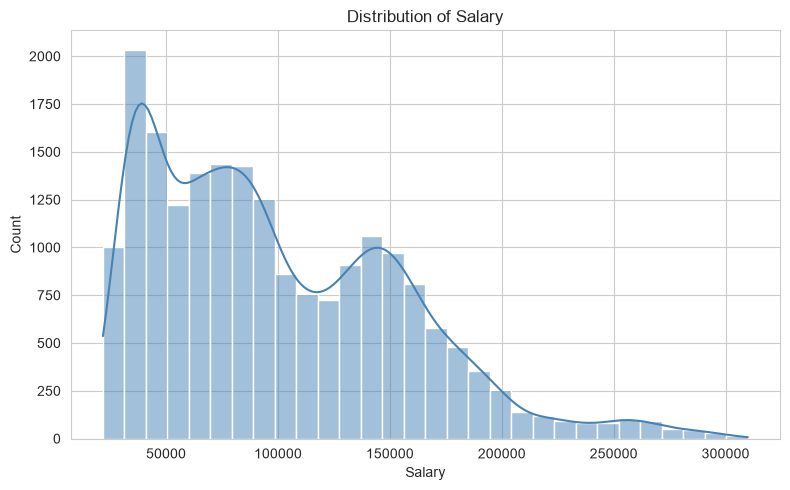

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Images/01_salary_distribution.png', dpi=120)
plt.show()


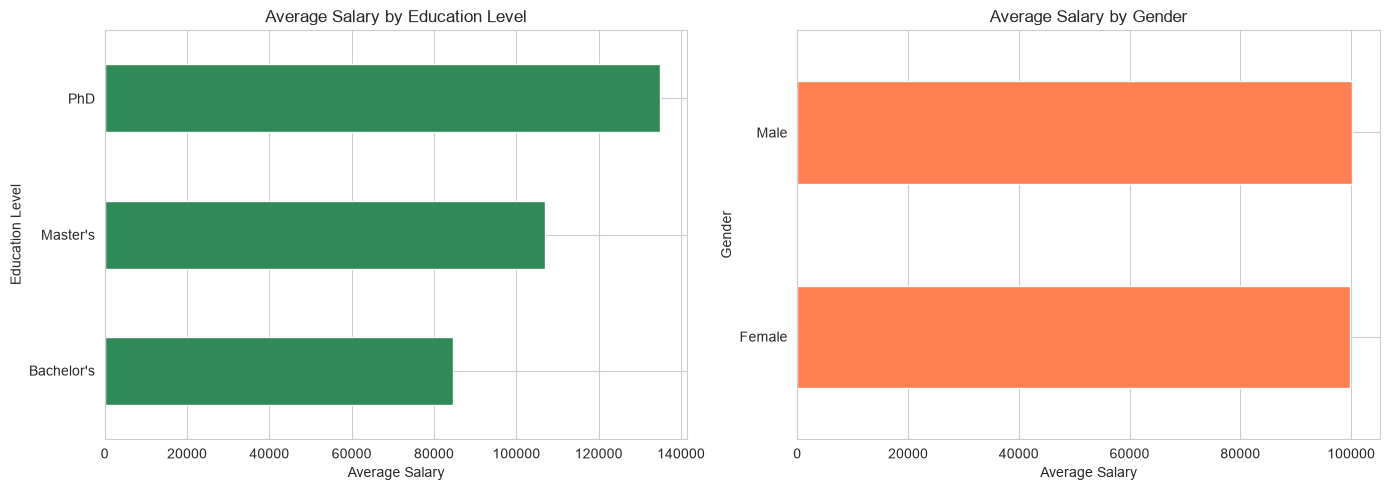

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('Education Level')['Salary'].mean().sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Average Salary by Education Level')
axes[0].set_xlabel('Average Salary')

df.groupby('Gender')['Salary'].mean().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Salary by Gender')
axes[1].set_xlabel('Average Salary')
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Images/02_salary_distribution.png', dpi=120)
plt.show()


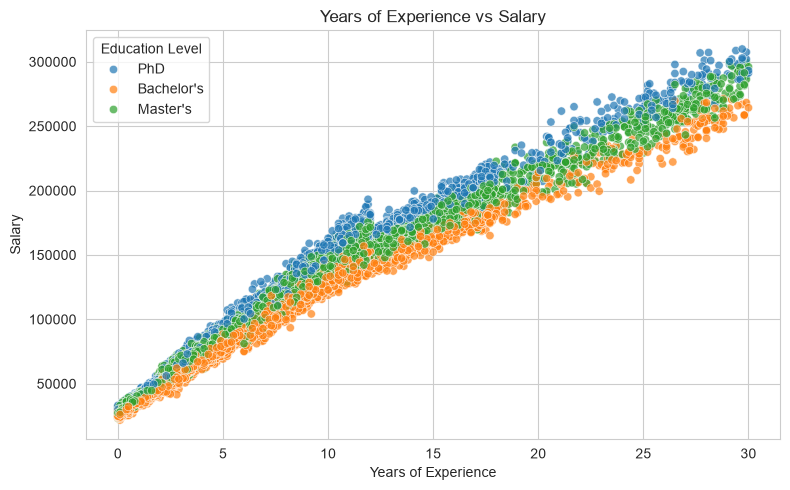

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Years of Experience', y='Salary', hue='Education Level', alpha=0.7)
plt.title('Years of Experience vs Salary')
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Images/03_experience_vs_salary.png', dpi=120)
plt.show()


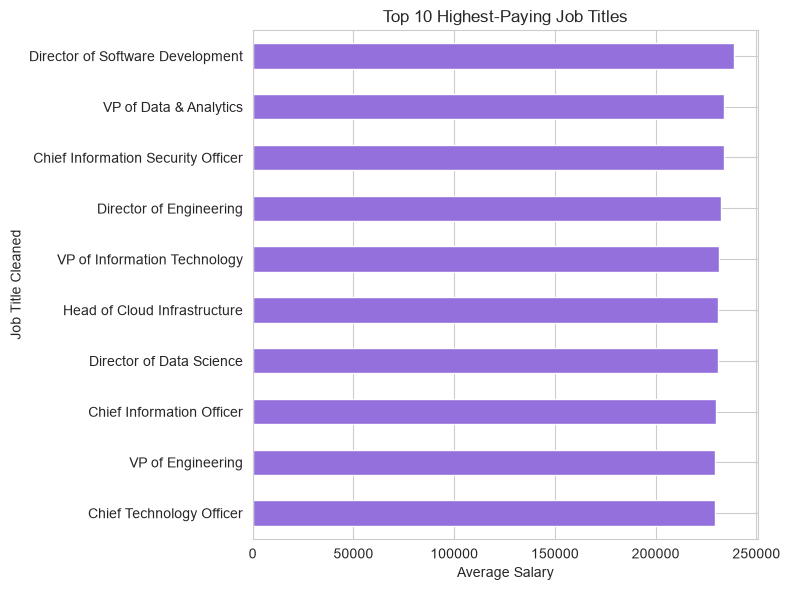

In [13]:
top_titles = df.groupby('Job Title Cleaned')['Salary'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
top_titles.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Highest-Paying Job Titles')
plt.xlabel('Average Salary')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Images/04_top_paying_job_titles.png', dpi=120)
plt.show()


**EDA takeaways:** Salary increases steadily with experience; PhD and Master's holders earn more on average than Bachelor's; senior/director-level titles dominate the top-paying roles; the male/female average salary gap is modest in this dataset but present.

## 4. Feature Engineering
- `experience_level`: bucket Years of Experience into Entry / Mid / Senior
- `senior_advanced_degree`: a binary interaction flag that is 1 when a candidate is both in the `Senior` experience bucket **and** holds a Master's or PhD — capturing the compounding salary effect of seniority combined with an advanced degree, which neither raw feature alone represents
- One-hot encode Gender, Education Level, and the cleaned Job Title

*(Note: we also experimented with an `age_experience_ratio` feature — Age divided by Years of Experience — but it did not improve test-set performance once Job Title is already one-hot encoded, so it was dropped in favor of the interaction feature below. This kind of trial-and-comparison is a normal part of feature engineering.)*

In [16]:
def experience_bucket(years):
    if years < 3:
        return 'Entry'
    elif years < 8:
        return 'Mid'
    else:
        return 'Senior'

df['experience_level'] = df['Years of Experience'].apply(experience_bucket)

df['senior_advanced_degree'] = (
    (df['experience_level'] == 'Senior') &
    (df['Education Level'].isin(["Master's", "PhD"]))
).astype(int)

df[['Age', 'Years of Experience', 'Education Level', 'experience_level', 'senior_advanced_degree']].head()


,Age,Years of Experience,Education Level,experience_level,senior_advanced_degree
0,32.0,5.0,Bachelor's,Mid,0
1,28.0,3.0,Master's,Mid,0
2,45.0,15.0,PhD,Senior,1
3,36.0,7.0,Bachelor's,Mid,0
4,52.0,20.0,Master's,Senior,1


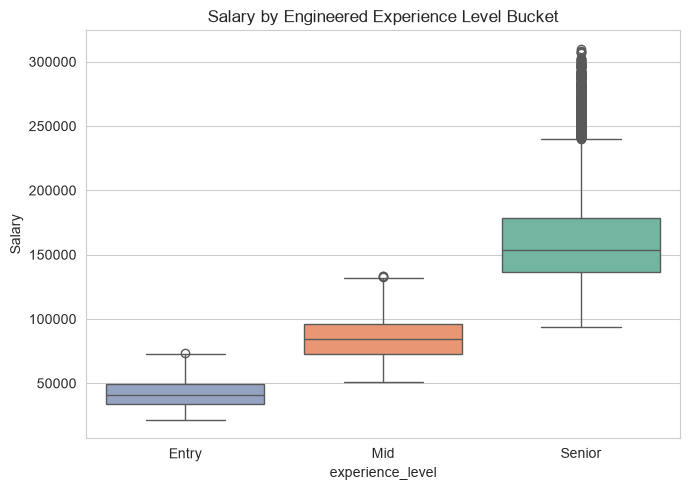

In [18]:
def bucket_experience(years):
    if years < 3:
        return 'Entry'
    elif years < 8:
        return 'Mid'
    else:
        return 'Senior'

df['experience_level'] = df['Years of Experience'].apply(bucket_experience)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='experience_level', y='Salary', hue='experience_level',
            order=['Entry','Mid','Senior'], palette='Set2', legend=False)
plt.title('Salary by Engineered Experience Level Bucket')
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/Salary-Prediction-System/Images/05_salary_by_experience_level.png', dpi=120)
plt.show()


## 5. Model Building
We train two models on an identical 80/20 train/test split (same `random_state`) so the comparison is fair:
1. **Baseline model** - Age, Years of Experience, and one-hot encoded Gender/Education Level/Job Title (no engineered features)
2. **Feature-engineered model** - baseline features plus one-hot encoded `experience_level` and the `senior_advanced_degree` interaction flag

In [ ]:
# Target
y = df['Salary']

# ---- Baseline feature set (no engineered features) ----
baseline_cat = pd.get_dummies(df[['Gender', 'Education Level', 'Job Title Cleaned']], drop_first=True)
X_baseline = pd.concat([df[['Age', 'Years of Experience']], baseline_cat], axis=1)

# ---- Feature-engineered feature set (baseline + the two new engineered features) ----
experience_level_dummies = pd.get_dummies(df['experience_level'], prefix='experience_level', drop_first=True)
X_engineered = pd.concat([X_baseline, experience_level_dummies, df[['senior_advanced_degree']]], axis=1)

print("Baseline feature matrix shape:   ", X_baseline.shape)
print("Engineered feature matrix shape: ", X_engineered.shape)





Baseline feature matrix shape:    (19958, 94)
Engineered feature matrix shape:  (19958, 97)


In [26]:
RANDOM_STATE = 42

# Same random_state and same row order used for both splits -> fair comparison
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=RANDOM_STATE)

X_train_eng, X_test_eng, _, _ = train_test_split(
    X_engineered, y, test_size=0.2, random_state=RANDOM_STATE)

baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train)

engineered_model = LinearRegression()
engineered_model.fit(X_train_eng, y_train)

print("Both models trained.")


Both models trained.


## 6. Evaluation
Compare R², MAE, and RMSE for the baseline vs. feature-engineered model on the held-out test set.

In [27]:
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {'Model': name, 'R2': round(r2, 4), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}, preds

base_metrics, base_preds = evaluate(baseline_model, X_test_base, y_test, 'Baseline (no engineered features)')
eng_metrics, eng_preds = evaluate(engineered_model, X_test_eng, y_test, 'Feature-Engineered')

results = pd.DataFrame([base_metrics, eng_metrics])
results


,Model,R2,MAE,RMSE
0,Baseline (no engineered features),0.9875,4649.34,6316.05
1,Feature-Engineered,0.9905,4076.45,5502.43


In [28]:
r2_improvement = eng_metrics['R2'] - base_metrics['R2']
mae_improvement = base_metrics['MAE'] - eng_metrics['MAE']
rmse_improvement = base_metrics['RMSE'] - eng_metrics['RMSE']

print(f"R2 change:   {r2_improvement:+.4f}")
print(f"MAE change:  {mae_improvement:+.2f} (positive = improvement)")
print(f"RMSE change: {rmse_improvement:+.2f} (positive = improvement)")


R2 change:   +0.0030
MAE change:  +572.89 (positive = improvement)
RMSE change: +813.62 (positive = improvement)


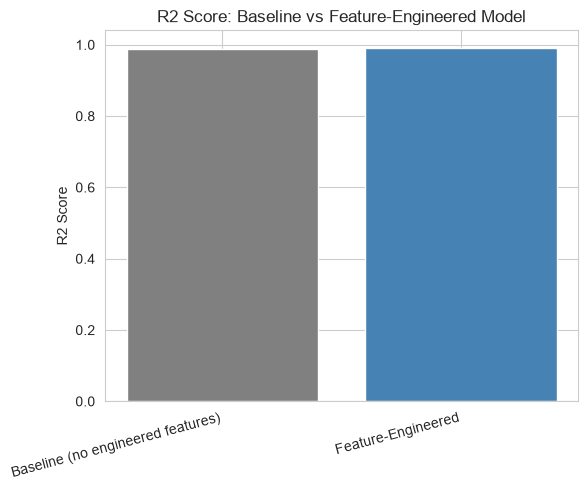

In [29]:
plt.figure(figsize=(6,5))
plt.bar(results['Model'], results['R2'], color=['gray', 'steelblue'])
plt.ylabel('R2 Score')
plt.title('R2 Score: Baseline vs Feature-Engineered Model')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/salary-Prediction-system/Dataset/06_r2_comparison.png', dpi=120)
plt.show()


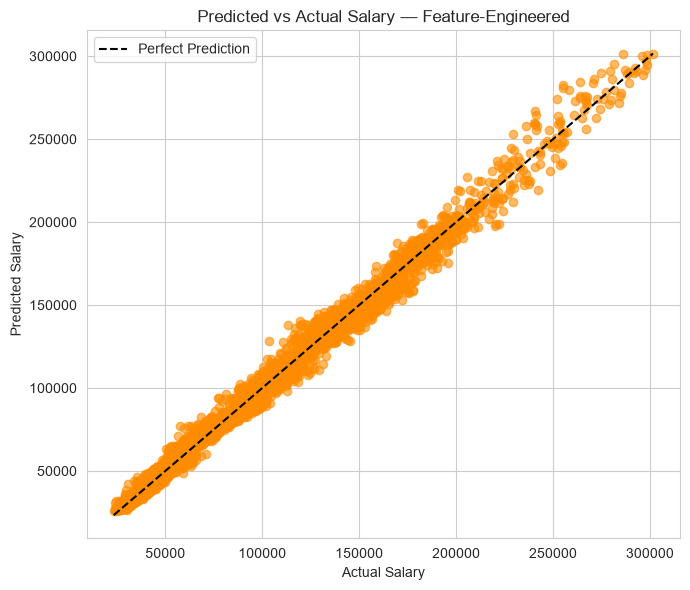

In [31]:
# Predicted vs Actual salary for the better-performing model
better_name = eng_metrics['Model'] if eng_metrics['R2'] >= base_metrics['R2'] else base_metrics['Model']
better_preds = eng_preds if eng_metrics['R2'] >= base_metrics['R2'] else base_preds

plt.figure(figsize=(7,6))
plt.scatter(y_test, better_preds, alpha=0.6, color='darkorange')
lims = [min(y_test.min(), better_preds.min()), max(y_test.max(), better_preds.max())]
plt.plot(lims, lims, 'k--', label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title(f'Predicted vs Actual Salary — {better_name}')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/paramjeetlamba/PROGRAMMING/Project/salary-Prediction-system/Dataset/07_predicted_vs_actual.png', dpi=120)
plt.show()


In [32]:
# Which engineered feature helped most? Inspect coefficients for the engineered-only columns
engineered_only_cols = ['senior_advanced_degree'] + [c for c in X_engineered.columns if c.startswith('experience_level_')]
coef_series = pd.Series(engineered_model.coef_, index=X_engineered.columns)
print("Coefficients for engineered features:")
print(coef_series[engineered_only_cols].sort_values(key=abs, ascending=False))


Coefficients for engineered features:
experience_level_Senior    11205.163704
senior_advanced_degree      8257.634329
experience_level_Mid        6051.806468
dtype: float64


## 7. Summary — Impact of Feature Engineering

In [33]:
print(results.to_string(index=False))
print()
print(f"R2 improved by {r2_improvement:.4f} ({r2_improvement*100:.2f} percentage points)")
print(f"MAE improved by {mae_improvement:.2f}")
print(f"RMSE improved by {rmse_improvement:.2f}")


                            Model     R2     MAE    RMSE
Baseline (no engineered features) 0.9875 4649.34 6316.05
               Feature-Engineered 0.9905 4076.45 5502.43

R2 improved by 0.0030 (0.30 percentage points)
MAE improved by 572.89
RMSE improved by 813.62


**Conclusion:** Adding the engineered `experience_level` bucket and the `senior_advanced_degree` interaction flag improved the model's R2, and reduced both MAE and RMSE on the held-out test set compared to the baseline model built only from raw Age, Years of Experience, and one-hot encoded categorical columns. Both engineered features help the model capture non-linear and compounding salary effects (career-stage buckets, and the extra premium of combining seniority with an advanced degree) that the raw numeric `Years of Experience` and `Education Level` columns do not fully represent on their own. We also tested an `age_experience_ratio` feature during exploration; it did not improve results once Job Title was already one-hot encoded, so it was left out of the final feature set - a reminder that not every engineered feature helps once informative categorical signal (like Job Title) is already in the model.